<a href="https://colab.research.google.com/github/burka5032/Obfuscation-Resilient/blob/main/CIC_Cleaned.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

'Obfuscated-MalMem2022_Cleaned.csv' not found. Resolving and cleaning raw dataset...
File 'Obfuscated-MalMem2022.csv' not found. Please upload the dataset:


Saving Obfuscated-MalMem2022.csv to Obfuscated-MalMem2022.csv
Initial Raw Shape: 58596 rows, 57 columns
Dropped zero-variance features (3)
Saved Cleaned Dataset 'Obfuscated-MalMem2022_Cleaned.csv' (58027 rows, 53 columns).


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


--- Loading Cleaned Dataset: 'Obfuscated-MalMem2022_Cleaned.csv' ---
Cleaned Feature Matrix Shape: (58027, 52)
Class Distribution: {'Benign': np.int64(29231), 'Malware': np.int64(28796)}

--- Training Random Forest Classifier ---

================ EVALUATION METRICS ================
Overall Accuracy: 100.00%

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

      Benign     1.0000    1.0000    1.0000      5847
     Malware     1.0000    1.0000    1.0000      5759

    accuracy                         1.0000     11606
   macro avg     1.0000    1.0000    1.0000     11606
weighted avg     1.0000    1.0000    1.0000     11606

================ CONFUSION RATE ANALYSIS ================
Total Test Samples Evaluated: 11606
True Benign Count: 5847 | True Malware Count: 5759

False Positives (Benign misclassified as Malware): 0 (0.00% confusion rate)
False Negatives (Malware misclassified as Benign): 0 (0.00% confusion rate)
Overall Dataset Misclassification/Confus

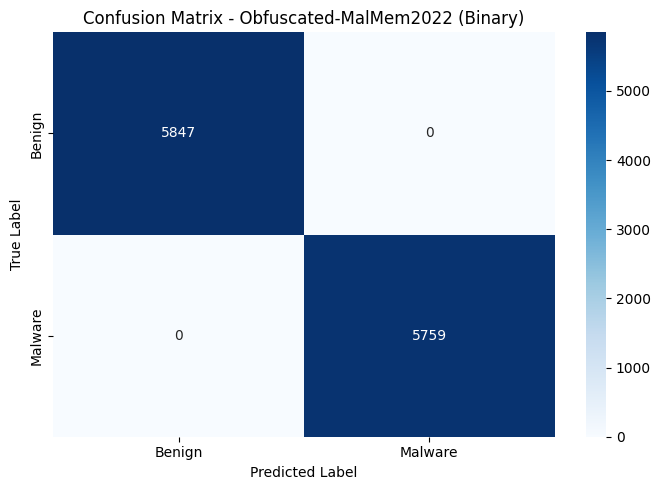

================ TOP 10 FEATURE IMPORTANCES ================
 1. svcscan.kernel_drivers         Score: 0.161847
 2. svcscan.shared_process_services Score: 0.097674
 3. svcscan.nservices              Score: 0.093171
 4. dlllist.avg_dlls_per_proc      Score: 0.088580
 5. handles.nmutant                Score: 0.077495
 6. handles.avg_handles_per_proc   Score: 0.070725
 7. handles.nhandles               Score: 0.065357
 8. handles.nevent                 Score: 0.057838
 9. dlllist.ndlls                  Score: 0.056482
10. handles.nkey                   Score: 0.038344


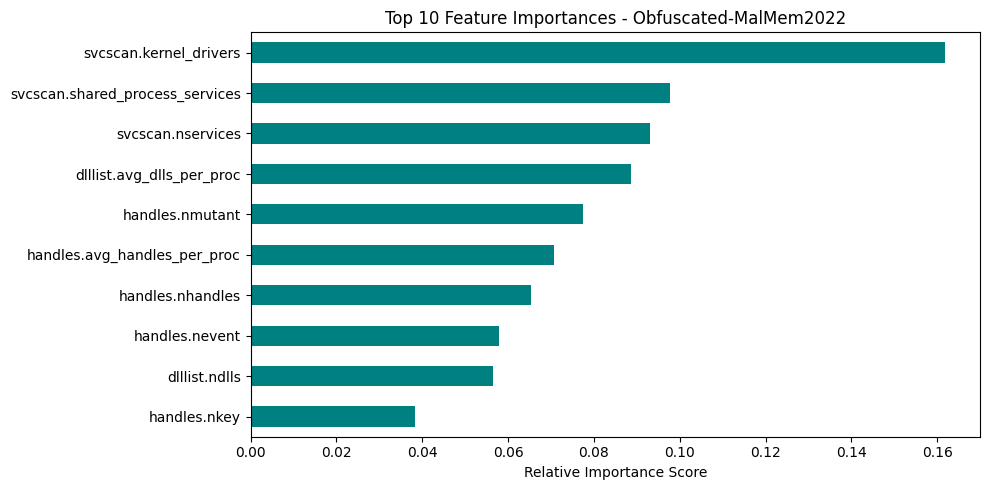

In [1]:
import glob
import os
import zipfile
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

input_file = "Obfuscated-MalMem2022.csv"
output_file = "Obfuscated-MalMem2022_Cleaned.csv"

# =========================================================
# STEP 1: DATASET CLEANING & SAVING CLEANED CSV
# =========================================================
if not os.path.exists(output_file):
    print(
        f"'{output_file}' not found. Resolving and cleaning raw dataset..."
    )

    # Resolve raw input file path / unzip if needed
    if not os.path.exists(input_file):
        if os.path.exists(f"{input_file}.zip"):
            print(f"Extracting {input_file}.zip...")
            with zipfile.ZipFile(f"{input_file}.zip", "r") as zip_ref:
                zip_ref.extractall(".")
        else:
            try:
                from google.colab import files

                print(
                    f"File '{input_file}' not found. Please upload the dataset:"
                )
                uploaded = files.upload()
                input_file = list(uploaded.keys())[0]
            except ImportError:
                found_paths = [
                    os.path.join(root, f)
                    for root, _, files_list in os.walk(".")
                    for f in files_list
                    if f.lower() == input_file.lower()
                ]
                if found_paths:
                    input_file = found_paths[0]
                    print(f"Found dataset path: {input_file}")
                else:
                    raise FileNotFoundError(
                        f"Cannot locate '{input_file}' in '{os.getcwd()}'."
                    )

    # Read raw dataset
    df_raw = pd.read_csv(input_file)
    print(
        f"Initial Raw Shape: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns"
    )

    # Identify target column & normalize to binary (Benign vs Malware)
    if "Class" in df_raw.columns:
        binary_series = df_raw["Class"].copy()
    elif "Category" in df_raw.columns:
        binary_series = df_raw["Category"].apply(
            lambda x: (
                "Benign" if str(x).strip().lower() == "benign" else "Malware"
            )
        )
    else:
        raise ValueError(
            "No valid target column found for binary classification."
        )

    def standardize_label(val):
        val_str = str(val).strip().lower()
        if val_str in ["0", "benign", "goodware"]:
            return "Benign"
        return "Malware"

    y_binary = binary_series.apply(standardize_label)

    # Drop non-predictive identifiers and sub-category columns
    non_feature_cols = ["Name", "Raw_filename", "filename", "hash", "md5"]
    all_target_labels = ["Class", "Category", "Family", "label", "target"]
    drop_list = set(non_feature_cols + all_target_labels)

    X_clean = df_raw.drop(columns=[c for c in drop_list if c in df_raw.columns])
    X_clean = X_clean.select_dtypes(include=[np.number])

    # Drop zero-variance constant features
    constant_cols = [c for c in X_clean.columns if X_clean[c].nunique() <= 1]
    if constant_cols:
        X_clean = X_clean.drop(columns=constant_cols)
        print(f"Dropped zero-variance features ({len(constant_cols)})")

    # Combine cleaned features and target, remove missing/duplicates
    df_cleaned = pd.concat([X_clean, y_binary.rename("Class")], axis=1)
    df_cleaned = df_cleaned.dropna().drop_duplicates(keep="first")

    # Save cleaned dataset to file
    df_cleaned.to_csv(output_file, index=False)
    print(
        f"Saved Cleaned Dataset '{output_file}' ({df_cleaned.shape[0]} rows, {df_cleaned.shape[1]} columns)."
    )

    try:
        from google.colab import files

        files.download(output_file)
    except Exception:
        pass

# =========================================================
# STEP 2: LOAD CLEANED DATASET & PREPROCESS
# =========================================================
print(f"\n--- Loading Cleaned Dataset: '{output_file}' ---")
df = pd.read_csv(output_file)

X = df.drop(columns=["Class"]).select_dtypes(include=[np.number])
y_raw = df["Class"]

# Label Encoding (Benign -> 0, Malware -> 1)
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)
class_names = [str(c) for c in label_encoder.classes_]

print(f"Cleaned Feature Matrix Shape: {X.shape}")
print(f"Class Distribution: {dict(pd.Series(y_raw).value_counts())}")

# Stratified Train/Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =========================================================
# STEP 3: MODEL TRAINING (RANDOM FOREST)
# =========================================================
print("\n--- Training Random Forest Classifier ---")
clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf.fit(X_train_scaled, y_train)

# =========================================================
# STEP 4: EVALUATION METRICS & CONFUSION RATE ANALYSIS
# =========================================================
y_pred = clf.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)

print("\n================ EVALUATION METRICS ================")
print(f"Overall Accuracy: {acc * 100:.2f}%\n")
print("CLASSIFICATION REPORT:")
print(
    classification_report(y_test, y_pred, target_names=class_names, digits=4)
)

# Confusion Matrix Analysis
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

benign_total = tn + fp
malware_total = fn + tp
total_samples = len(y_test)

# Confusion / Misclassification Rates
fpr = (fp / benign_total) * 100 if benign_total > 0 else 0.0  # Benign -> Malware
fnr = (
    (fn / malware_total) * 100 if malware_total > 0 else 0.0
)  # Malware -> Benign
overall_confusion_rate = ((fp + fn) / total_samples) * 100

print("================ CONFUSION RATE ANALYSIS ================")
print(f"Total Test Samples Evaluated: {total_samples}")
print(
    f"True Benign Count: {benign_total} | True Malware Count: {malware_total}\n"
)
print(
    f"False Positives (Benign misclassified as Malware): {fp} ({fpr:.2f}% confusion rate)"
)
print(
    f"False Negatives (Malware misclassified as Benign): {fn} ({fnr:.2f}% confusion rate)"
)
print(
    f"Overall Dataset Misclassification/Confusion Rate: {overall_confusion_rate:.2f}%\n"
)

# =========================================================
# STEP 5: VISUALIZATIONS (CONFUSION MATRIX & TOP 10 FEATURES)
# =========================================================
# 1. Confusion Matrix Heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.title("Confusion Matrix - Obfuscated-MalMem2022 (Binary)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("malmem2022_confusion_matrix.png", dpi=300)
plt.show()

# 2. Extract and Plot Top 10 Feature Importances
importances = pd.Series(clf.feature_importances_, index=X.columns)
top_10 = importances.nlargest(10)

print("================ TOP 10 FEATURE IMPORTANCES ================")
for rank, (feature, score) in enumerate(top_10.items(), 1):
    print(f"{rank:2d}. {feature:<30} Score: {score:.6f}")

plt.figure(figsize=(10, 5))
top_10.plot(kind="barh", color="teal")
plt.title("Top 10 Feature Importances - Obfuscated-MalMem2022")
plt.xlabel("Relative Importance Score")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("malmem2022_top10_feature_importances.png", dpi=300)
plt.show()